<a href="https://colab.research.google.com/github/jurischmi/Bachelorarbeit/blob/main/BachelorarbeitAnalysisCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

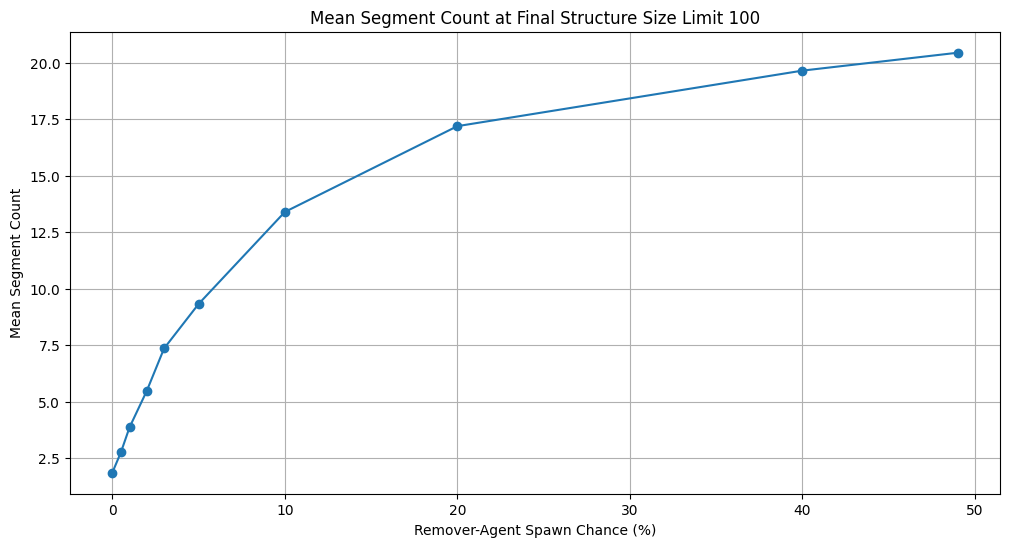

In [ ]:
#Figure 4

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataMAIN/segmentcount.csv")

# Only keep remover spawn chances from 0% to 20%
#df = df[(df["Factor 2"] >= 0) & (df["Factor 2"] <= 20)]

# Average segment count for each remover spawn chance
grouped = (
    df.groupby("Factor 2")["Result 1"]
      .agg(["mean","median"])
      .reset_index()
)

factor = grouped["Factor 2"]
mean_result = grouped["mean"]
median_result = grouped["median"]
plt.figure(figsize=(12,6))

plt.plot(
    factor,
    mean_result,
    marker='o',
    label="Mean"
)

# Median
#plt.plot(factor, median_result, marker='s', label="Median")

plt.xlabel("Remover-Agent Spawn Chance (%)")
plt.ylabel("Mean Segment Count")
plt.title("Mean Segment Count at Final Structure Size Limit 100")

plt.grid(True)
plt.show()

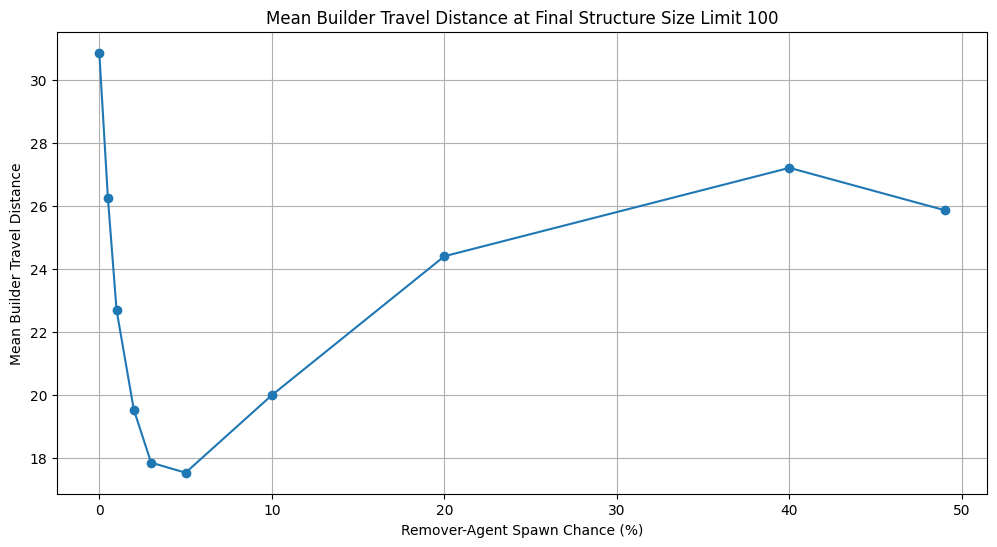

In [ ]:
#Figure 5.1

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataMAIN/meantraveldistance.csv")

# Only keep remover spawn chances from 0% to 20%
df = df[(df["Factor 2"] >= 0) & (df["Factor 2"] <= 50)]

# Average segment count for each remover spawn chance
grouped = (
    df.groupby("Factor 2")["Result 1"]
      .agg(["mean","median"])
      .reset_index()
)

factor = grouped["Factor 2"]
mean_result = grouped["mean"]
median_result = grouped["median"]
plt.figure(figsize=(12,6))

plt.plot(
    factor,
    mean_result,
    marker='o',
    label="Mean"
)

# Median
#plt.plot(factor, median_result, marker='s', label="Median")

plt.xlabel("Remover-Agent Spawn Chance (%)")
plt.ylabel("Mean Builder Travel Distance")
plt.title("Mean Builder Travel Distance at Final Structure Size Limit 100")

plt.grid(True)
plt.show()

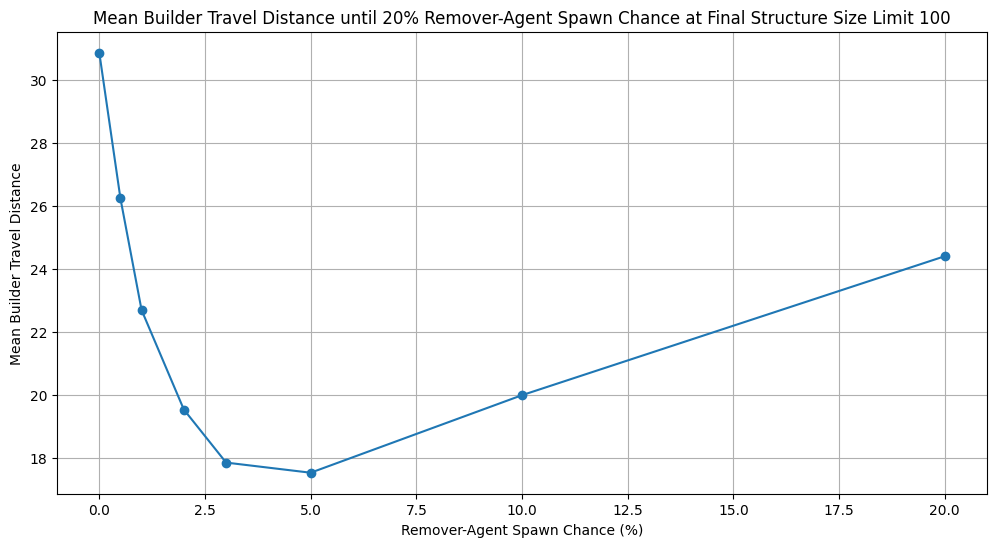

In [ ]:
#Figure 5.2

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataMAIN/meantraveldistance.csv")

# Only keep remover spawn chances from 0% to 20%
df = df[(df["Factor 2"] >= 0) & (df["Factor 2"] <= 20)]

# Average segment count for each remover spawn chance
grouped = (
    df.groupby("Factor 2")["Result 1"]
      .agg(["mean"])
      .reset_index()
)

factor = grouped["Factor 2"]
mean_result = grouped["mean"]
plt.figure(figsize=(12,6))

plt.errorbar(
    factor,
    mean_result,
    marker='o',
    capsize=5
)

plt.xlabel("Remover-Agent Spawn Chance (%)")
plt.ylabel("Mean Builder Travel Distance")
plt.title("Mean Builder Travel Distance until 20% Remover-Agent Spawn Chance at Final Structure Size Limit 100")

plt.grid(True)
plt.show()

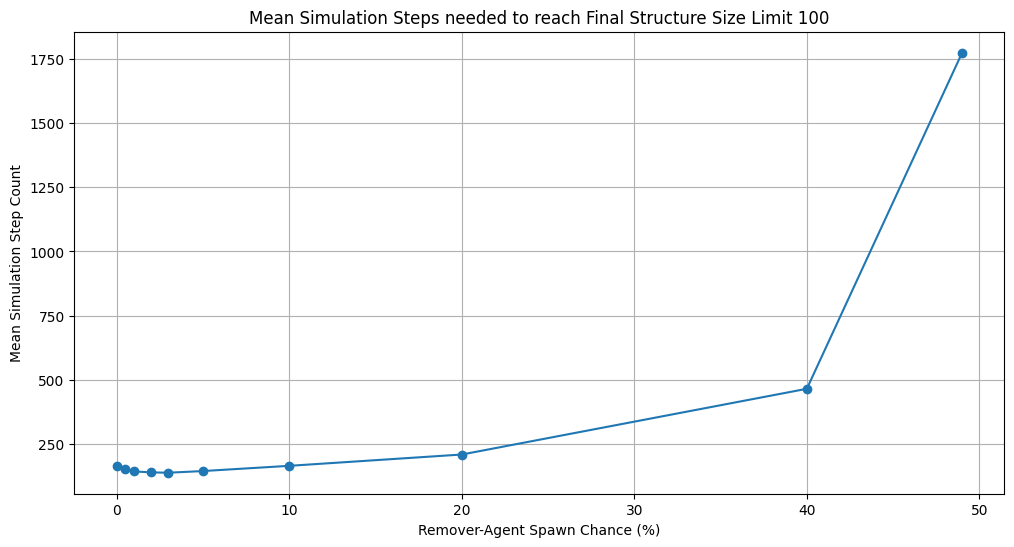

In [ ]:
#Figure 6.1

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataMAIN/simulationstepscount.csv")

# Only keep remover spawn chances from 0% to 20%
df = df[(df["Factor 2"] >= 0) & (df["Factor 2"] <= 50)]

# Average segment count for each remover spawn chance
grouped = (
    df.groupby("Factor 2")["Result 1"]
      .agg(["mean","median"])
      .reset_index()
)

factor = grouped["Factor 2"]
mean_result = grouped["mean"]
median_result = grouped["median"]
plt.figure(figsize=(12,6))

plt.plot(
    factor,
    mean_result,
    marker='o',
    label="Mean"
)
#plt.yscale("log")
# Median
#plt.plot(factor, median_result, marker='s', label="Median")

plt.xlabel("Remover-Agent Spawn Chance (%)")
plt.ylabel("Mean Simulation Step Count")
plt.title("Mean Simulation Steps needed to reach Final Structure Size Limit 100")

plt.grid(True)
plt.show()

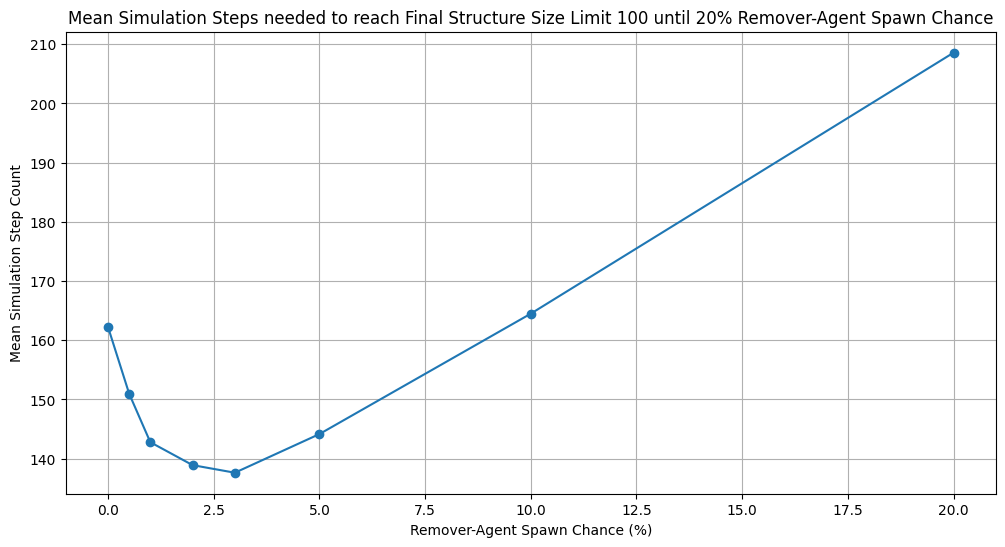

In [ ]:
#Figure 6.2

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataMAIN/simulationstepscount.csv")

# Only keep remover spawn chances from 0% to 20%
df = df[(df["Factor 2"] >= 0) & (df["Factor 2"] <= 20)]

# Average segment count for each remover spawn chance
grouped = (
    df.groupby("Factor 2")["Result 1"]
      .agg(["mean"])
      .reset_index()
)

factor = grouped["Factor 2"]
mean_result = grouped["mean"]
plt.figure(figsize=(12,6))

plt.errorbar(
    factor,
    mean_result,
    marker='o',
    capsize=5
)


plt.xlabel("Remover-Agent Spawn Chance (%)")
plt.ylabel("Mean Simulation Step Count")
plt.title("Mean Simulation Steps needed to reach Final Structure Size Limit 100 until 20% Remover-Agent Spawn Chance")

plt.grid(True)
plt.show()

Index(['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5', 'Result 1'], dtype='object')

Descriptive statistics:
               Group    n     Mean      SD  Median   IQR  95% CI lower  \
0  0% Remover Agents  500  162.214  13.629   159.0   2.0       161.016   
1  3% Remover Agents  500  137.612  15.021   135.0  22.0       136.292   

   95% CI upper  
0       163.412  
1       138.932  

Welch's t-test:
two-sided p = 1.4973044965419455e-121
one-sided p = 7.486522482709727e-122
mean difference, 0% - 3% = 24.602000000000004
relative improvement = 15.166385145548475 %

Mann-Whitney U test:
U = 23711.0
p = 7.753719053323375e-110


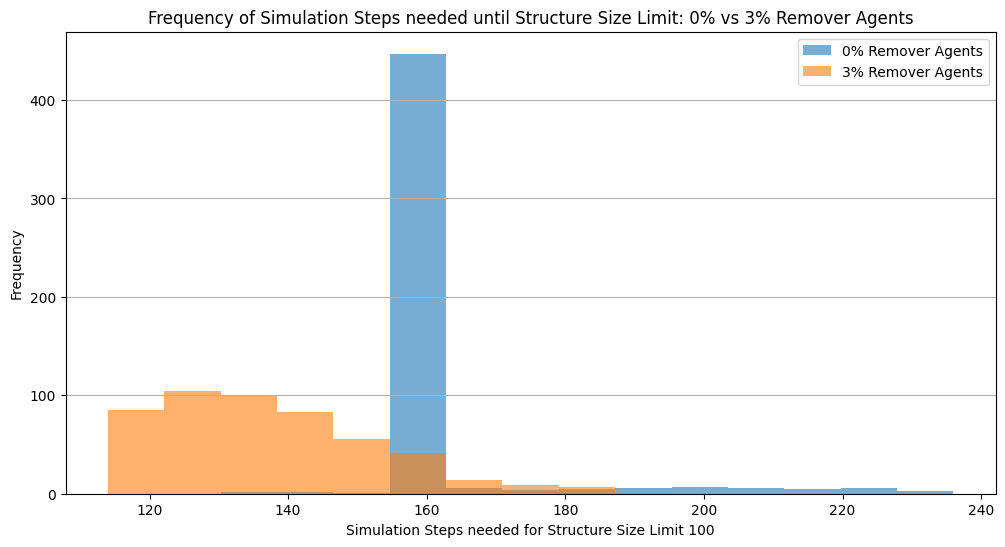

In [ ]:
# Figure 7 + descriptive statistics table

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("dataMAIN/simulationstepscount.csv")

print(df.columns)

# Adjust these if needed
remover_column = "Factor 2"
result_column = "Result 1"

# Split data
iterations_0 = df[df[remover_column] == 0][result_column].dropna()
iterations_3 = df[df[remover_column] == 3][result_column].dropna()

# Descriptive statistics function
def descriptive_statistics(values, label):
    values = pd.Series(values).dropna()

    n = len(values)
    mean = values.mean()
    sd = values.std(ddof=1)
    median = values.median()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    sem = sd / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_low = mean - t_crit * sem
    ci_high = mean + t_crit * sem

    return {
        "Group": label,
        "n": n,
        "Mean": mean,
        "SD": sd,
        "Median": median,
        "IQR": iqr,
        "95% CI lower": ci_low,
        "95% CI upper": ci_high
    }

summary_table = pd.DataFrame([
    descriptive_statistics(iterations_0, "0% Remover Agents"),
    descriptive_statistics(iterations_3, "3% Remover Agents")
])

# Round for nicer display
summary_table_rounded = summary_table.round(3)

print("\nDescriptive statistics:")
print(summary_table_rounded)

# Welch's t-test
t_stat, p_value_two_sided = stats.ttest_ind(
    iterations_3,
    iterations_0,
    equal_var=False
)

t_stat_one_sided, p_value_one_sided = stats.ttest_ind(
    iterations_3,
    iterations_0,
    equal_var=False,
    alternative="less"
)

mean_difference = iterations_0.mean() - iterations_3.mean()
relative_improvement = mean_difference / iterations_0.mean() * 100

print("\nWelch's t-test:")
print("two-sided p =", p_value_two_sided)
print("one-sided p =", p_value_one_sided)
print("mean difference, 0% - 3% =", mean_difference)
print("relative improvement =", relative_improvement, "%")

# Mann-Whitney U test
u_stat, p_mw = stats.mannwhitneyu(
    iterations_3,
    iterations_0,
    alternative="less"
)

print("\nMann-Whitney U test:")
print("U =", u_stat)
print("p =", p_mw)

combined = pd.concat([iterations_0, iterations_3])

bins = np.linspace(
    combined.min(),
    combined.max(),
    16
)
# Histogram
plt.figure(figsize=(12, 6))

plt.hist(
    iterations_0,
    bins=bins,
    alpha=0.6,
    label="0% Remover Agents"
)

plt.hist(
    iterations_3,
    bins=bins,
    alpha=0.6,
    label="3% Remover Agents"
)

plt.xlabel("Simulation Steps needed for Structure Size Limit 100")
plt.ylabel("Frequency")
plt.title("Frequency of Simulation Steps needed until Structure Size Limit: 0% vs 3% Remover Agents")
plt.legend()
plt.grid(axis="y")
plt.show()

        Experiment  Factor 2       mean       std     median  count
0   Neutral agents       0.0  30.793222  5.600364  29.331224    500
1   Neutral agents       0.5  30.902587  5.374780  29.253164    500
2   Neutral agents       1.0  30.607844  5.206375  29.275308    500
3   Neutral agents       2.0  30.372093  4.851624  29.277585    500
4   Neutral agents       3.0  30.629175  5.701579  29.301579    500
5   Neutral agents       5.0  30.385056  5.430943  29.310682    500
6   Neutral agents      10.0  29.834113  5.117274  29.290307    500
7   Neutral agents      20.0  29.505793  4.753554  29.115255    500
8   Neutral agents      40.0  29.765356  3.965919  29.110282    500
9   Neutral agents      49.0  29.401539  4.439307  28.953954    500
10  Remover agents       0.0  30.875762  5.144305  29.384862    500
11  Remover agents       0.5  26.247678  7.316726  28.540765    500
12  Remover agents       1.0  22.703614  6.801923  21.975589    500
13  Remover agents       2.0  19.543198  5.85279

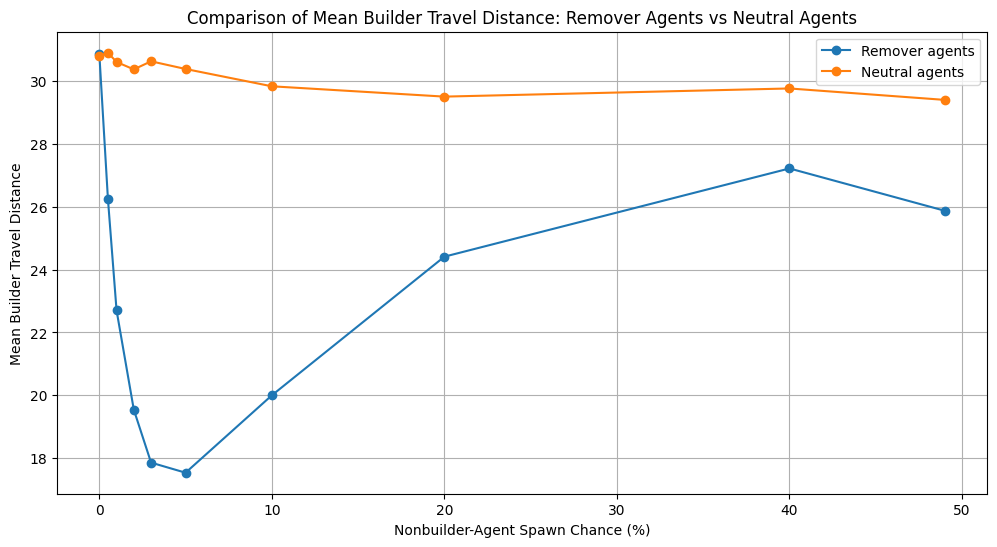


Welch's t-test results:
   Spawn Chance  Remover Mean  Neutral Mean  Difference Remover - Neutral  \
0           0.0     30.875762     30.793222                      0.082540   
1           0.5     26.247678     30.902587                     -4.654909   
2           1.0     22.703614     30.607844                     -7.904230   
3           2.0     19.543198     30.372093                    -10.828895   
4           3.0     17.859086     30.629175                    -12.770089   
5           5.0     17.537137     30.385056                    -12.847919   
6          10.0     19.999899     29.834113                     -9.834213   
7          20.0     24.412515     29.505793                     -5.093278   
8          40.0     27.219914     29.765356                     -2.545442   
9          49.0     25.873607     29.401539                     -3.527932   

           t              p  n Remover  n Neutral  
0   0.242706   8.082836e-01        500        500  
1 -11.464963   1.570783

In [11]:
#Figure 9 + descriptive statistics table

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Settings

normal_folder = "dataMAIN"
control_folder = "dataNEUTRAL"

file_name = "meantraveldistance.csv"   # change this, e.g. "segmentcount.csv"
spawn_column = "Factor 2"
result_column = "Result 1"

# Optional: only display spawn chances from 0% to 50%
min_spawn = 0
max_spawn = 50

# Load data
normal_df = pd.read_csv(f"{normal_folder}/{file_name}")
control_df = pd.read_csv(f"{control_folder}/{file_name}")

normal_df["Experiment"] = "Remover agents"
control_df["Experiment"] = "Neutral agents"

df = pd.concat([normal_df, control_df], ignore_index=True)

# Only keep selected spawn chances
df = df[(df[spawn_column] >= min_spawn) & (df[spawn_column] <= max_spawn)]

# Summary statistics
summary = (
    df.groupby(["Experiment", spawn_column])[result_column]
      .agg(["mean", "std", "median", "count"])
      .reset_index()
)

print(summary)

# Plot mean ± standard error
plt.figure(figsize=(12, 6))

for experiment_name in ["Remover agents", "Neutral agents"]:
    subset = summary[summary["Experiment"] == experiment_name]

    plt.errorbar(
        subset[spawn_column],
        subset["mean"],
        marker="o",
        capsize=5,
        label=experiment_name
    )

plt.xlabel("Nonbuilder-Agent Spawn Chance (%)")
plt.ylabel("Mean Builder Travel Distance")
plt.title(f"Comparison of Mean Builder Travel Distance: Remover Agents vs Neutral Agents")
plt.legend()
plt.grid(True)
plt.show()

# Welch's t-test for each spawn chance
test_results = []

spawn_values = sorted(df[spawn_column].unique())

for spawn in spawn_values:
    remover_values = df[
        (df["Experiment"] == "Remover agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    neutral_values = df[
        (df["Experiment"] == "Neutral agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    if len(remover_values) > 1 and len(neutral_values) > 1:
        t_stat, p_value = stats.ttest_ind(
            remover_values,
            neutral_values,
            equal_var=False
        )

        test_results.append({
            "Spawn Chance": spawn,
            "Remover Mean": remover_values.mean(),
            "Neutral Mean": neutral_values.mean(),
            "Difference Remover - Neutral": remover_values.mean() - neutral_values.mean(),
            "t": t_stat,
            "p": p_value,
            "n Remover": len(remover_values),
            "n Neutral": len(neutral_values)
        })

test_df = pd.DataFrame(test_results)

print("\nWelch's t-test results:")
print(test_df)

        Experiment  Factor 2    mean       std  median  count
0   Neutral agents       0.0   1.772  2.792061     1.0    500
1   Neutral agents       0.5   1.872  2.818422     1.0    500
2   Neutral agents       1.0   1.748  2.815733     1.0    500
3   Neutral agents       2.0   1.764  2.980280     1.0    500
4   Neutral agents       3.0   1.788  3.014171     1.0    500
5   Neutral agents       5.0   2.396  4.177809     1.0    500
6   Neutral agents      10.0   3.260  5.286615     1.0    500
7   Neutral agents      20.0   4.192  6.051477     1.0    500
8   Neutral agents      40.0   3.052  3.882711     1.0    500
9   Neutral agents      49.0   3.348  4.003868     1.0    500
10  Remover agents       0.0   1.852  2.859799     1.0    500
11  Remover agents       0.5   2.758  2.935416     2.0    500
12  Remover agents       1.0   3.862  3.430232     3.0    500
13  Remover agents       2.0   5.478  4.076119     4.0    500
14  Remover agents       3.0   7.352  4.885471     6.0    500
15  Remo

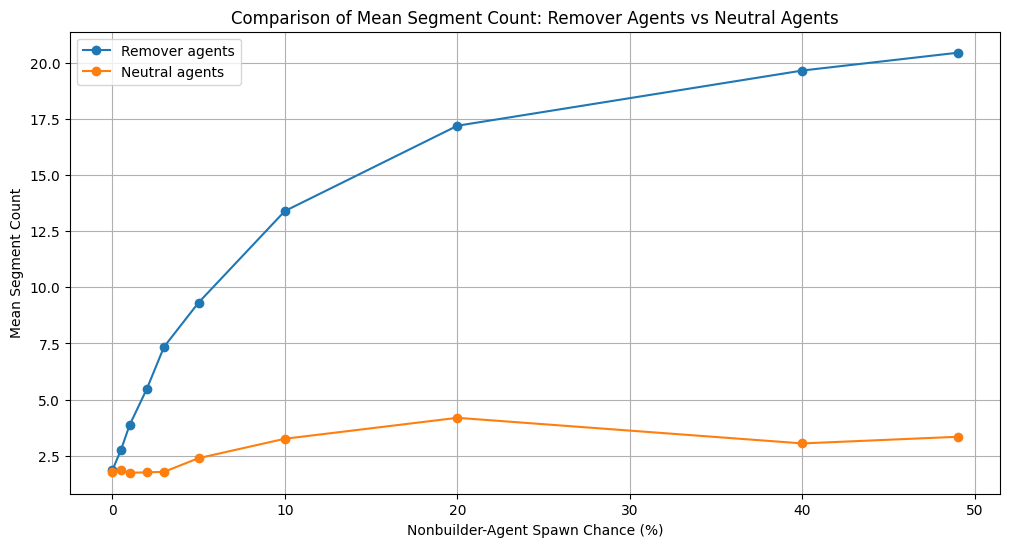


Welch's t-test results:
   Spawn Chance  Remover Mean  Neutral Mean  Difference Remover - Neutral  \
0           0.0         1.852         1.772                         0.080   
1           0.5         2.758         1.872                         0.886   
2           1.0         3.862         1.748                         2.114   
3           2.0         5.478         1.764                         3.714   
4           3.0         7.352         1.788                         5.564   
5           5.0         9.320         2.396                         6.924   
6          10.0        13.394         3.260                        10.134   
7          20.0        17.192         4.192                        13.000   
8          40.0        19.650         3.052                        16.598   
9          49.0        20.442         3.348                        17.094   

           t              p  n Remover  n Neutral  
0   0.447577   6.545560e-01        500        500  
1   4.868400   1.307547

In [ ]:
#Figure 8 + descriptive statistics table

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Settings

normal_folder = "dataMAIN"
control_folder = "dataNEUTRAL"

file_name = "segmentcount.csv"   # change this, e.g. "segmentcount.csv"
spawn_column = "Factor 2"
result_column = "Result 1"

# Optional: only display spawn chances from 0% to 20%
min_spawn = 0
max_spawn = 50

# Load data
normal_df = pd.read_csv(f"{normal_folder}/{file_name}")
control_df = pd.read_csv(f"{control_folder}/{file_name}")

normal_df["Experiment"] = "Remover agents"
control_df["Experiment"] = "Neutral agents"

df = pd.concat([normal_df, control_df], ignore_index=True)

df = df[(df[spawn_column] >= min_spawn) & (df[spawn_column] <= max_spawn)]

# Summary statistics
summary = (
    df.groupby(["Experiment", spawn_column])[result_column]
      .agg(["mean", "std", "median", "count"])
      .reset_index()
)

print(summary)

# Plot mean
plt.figure(figsize=(12, 6))

for experiment_name in ["Remover agents", "Neutral agents"]:
    subset = summary[summary["Experiment"] == experiment_name]

    plt.errorbar(
        subset[spawn_column],
        subset["mean"],
        marker="o",
        capsize=5,
        label=experiment_name
    )

plt.xlabel("Nonbuilder-Agent Spawn Chance (%)")
plt.ylabel("Mean Segment Count")
plt.title(f"Comparison of Mean Segment Count: Remover Agents vs Neutral Agents")
plt.legend()
plt.grid(True)
plt.show()

# Welch's t-test for each spawn chance
test_results = []

spawn_values = sorted(df[spawn_column].unique())

for spawn in spawn_values:
    remover_values = df[
        (df["Experiment"] == "Remover agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    neutral_values = df[
        (df["Experiment"] == "Neutral agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    if len(remover_values) > 1 and len(neutral_values) > 1:
        t_stat, p_value = stats.ttest_ind(
            remover_values,
            neutral_values,
            equal_var=False
        )

        test_results.append({
            "Spawn Chance": spawn,
            "Remover Mean": remover_values.mean(),
            "Neutral Mean": neutral_values.mean(),
            "Difference Remover - Neutral": remover_values.mean() - neutral_values.mean(),
            "t": t_stat,
            "p": p_value,
            "n Remover": len(remover_values),
            "n Neutral": len(neutral_values)
        })

test_df = pd.DataFrame(test_results)

print("\nWelch's t-test results:")
print(test_df)

        Experiment  Factor 2      mean          std  median  count
0   Neutral agents       0.0   162.108    15.686825   159.0    500
1   Neutral agents       0.5   163.030    14.722180   159.0    500
2   Neutral agents       1.0   162.940    14.907746   160.0    500
3   Neutral agents       2.0   163.206    13.822652   160.0    500
4   Neutral agents       3.0   164.996    16.587413   161.5    500
5   Neutral agents       5.0   166.430    15.916021   164.0    500
6   Neutral agents      10.0   170.502    15.448992   169.0    500
7   Neutral agents      20.0   182.498    15.694925   183.0    500
8   Neutral agents      40.0   226.550    15.255851   226.0    500
9   Neutral agents      49.0   254.612    17.987455   252.5    500
10  Remover agents       0.0   162.214    13.629370   159.0    500
11  Remover agents       0.5   150.948    19.356411   157.0    500
12  Remover agents       1.0   142.768    16.983258   142.0    500
13  Remover agents       2.0   138.894    16.613693   136.0   

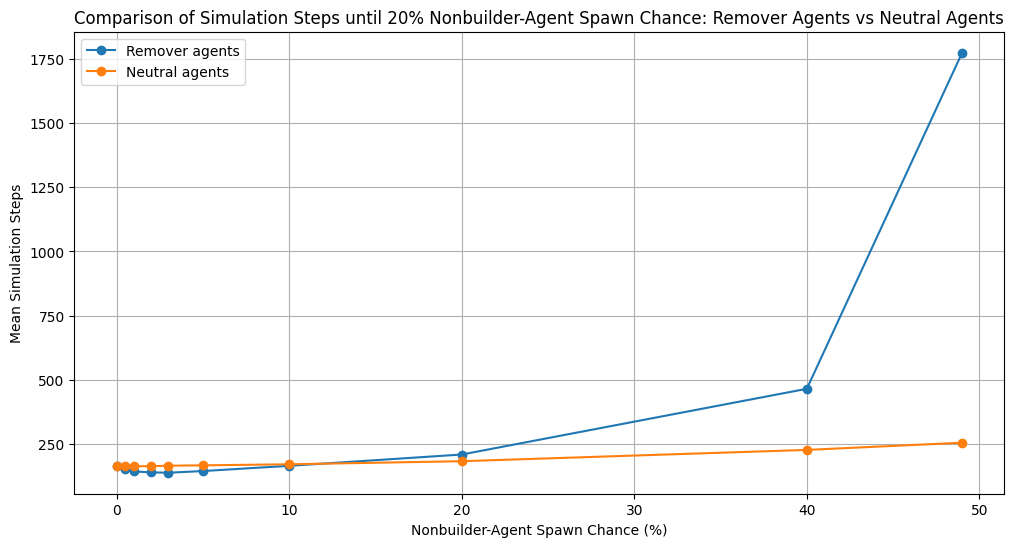


Welch's t-test results:
   Spawn Chance  Remover Mean  Neutral Mean  Difference Remover -  Neutral  \
0           0.0       162.214         3.348                        158.866   
1           0.5       150.948         3.348                        147.600   
2           1.0       142.768         3.348                        139.420   
3           2.0       138.894         3.348                        135.546   
4           3.0       137.612         3.348                        134.264   
5           5.0       144.142         3.348                        140.794   
6          10.0       164.482         3.348                        161.134   
7          20.0       208.566         3.348                        205.218   
8          40.0       464.764         3.348                        461.416   
9          49.0      1774.708         3.348                       1771.360   

            t              p  n Remover  n Neutral  
0  250.072197   0.000000e+00        500        500  
1  166.973

In [ ]:
#Figure 10(a) + descriptive statistics table

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Settings

normal_folder = "dataMAIN"
control_folder = "dataNEUTRAL"

file_name = "simulationstepscount.csv"   # change this, e.g. "segmentcount.csv"
spawn_column = "Factor 2"
result_column = "Result 1"

# Optional: only display spawn chances from 0% to 20%
min_spawn = 0
max_spawn = 50

# Load data
normal_df = pd.read_csv(f"{normal_folder}/{file_name}")
control_df = pd.read_csv(f"{control_folder}/{file_name}")

normal_df["Experiment"] = "Remover agents"
control_df["Experiment"] = "Neutral agents"

df = pd.concat([normal_df, control_df], ignore_index=True)

# Only keep selected spawn chances
df = df[(df[spawn_column] >= min_spawn) & (df[spawn_column] <= max_spawn)]

# Summary statistics
summary = (
    df.groupby(["Experiment", spawn_column])[result_column]
      .agg(["mean", "std", "median", "count"])
      .reset_index()
)

print(summary)

# Plot mean ± standard error
plt.figure(figsize=(12, 6))

for experiment_name in ["Remover agents", "Neutral agents"]:
    subset = summary[summary["Experiment"] == experiment_name]

    plt.errorbar(
        subset[spawn_column],
        subset["mean"],
        marker="o",
        capsize=5,
        label=experiment_name
    )

plt.xlabel("Nonbuilder-Agent Spawn Chance (%)")
plt.ylabel("Mean Simulation Steps")
plt.title(f"Comparison of Simulation Steps until 20% Nonbuilder-Agent Spawn Chance: Remover Agents vs Neutral Agents")
plt.legend()
plt.grid(True)
plt.show()

# Welch's t-test for each spawn chance
test_results = []

spawn_values = sorted(df[spawn_column].unique())

for spawn in spawn_values:
    remover_values = df[
        (df["Experiment"] == "Remover agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    skipped_values = df[
        (df["Experiment"] == "Neutral agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    if len(remover_values) > 1 and len(neutral_values) > 1:
        t_stat, p_value = stats.ttest_ind(
            remover_values,
            neutral_values,
            equal_var=False
        )

        test_results.append({
            "Spawn Chance": spawn,
            "Remover Mean": remover_values.mean(),
            "Neutral Mean": neutral_values.mean(),
            "Difference Remover -  Neutral": remover_values.mean() - neutral_values.mean(),
            "t": t_stat,
            "p": p_value,
            "n Remover": len(remover_values),
            "n Neutral": len(neutral_values)
        })

test_df = pd.DataFrame(test_results)

print("\nWelch's t-test results:")
print(test_df)

        Experiment  Factor 2     mean        std  median  count
0   Neutral agents       0.0  162.108  15.686825   159.0    500
1   Neutral agents       0.5  163.030  14.722180   159.0    500
2   Neutral agents       1.0  162.940  14.907746   160.0    500
3   Neutral agents       2.0  163.206  13.822652   160.0    500
4   Neutral agents       3.0  164.996  16.587413   161.5    500
5   Neutral agents       5.0  166.430  15.916021   164.0    500
6   Neutral agents      10.0  170.502  15.448992   169.0    500
7   Neutral agents      20.0  182.498  15.694925   183.0    500
8   Remover agents       0.0  162.214  13.629370   159.0    500
9   Remover agents       0.5  150.948  19.356411   157.0    500
10  Remover agents       1.0  142.768  16.983258   142.0    500
11  Remover agents       2.0  138.894  16.613693   136.0    500
12  Remover agents       3.0  137.612  15.020942   135.0    500
13  Remover agents       5.0  144.142  19.812089   141.0    500
14  Remover agents      10.0  164.482  2

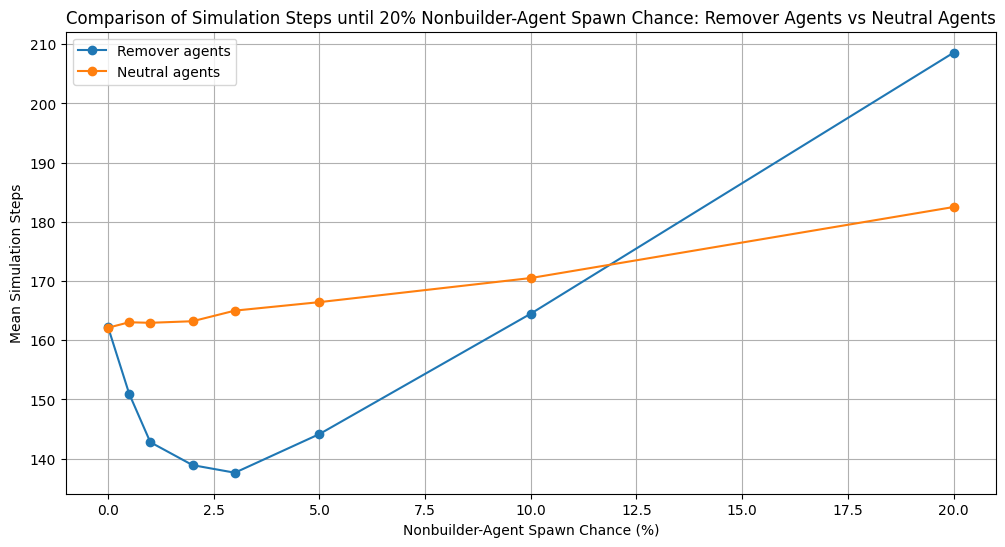


Welch's t-test results:
   Spawn Chance  Remover Mean  Neutral Mean  Difference Remover - Neutral  \
0           0.0       162.214       162.108                         0.106   
1           0.5       150.948       163.030                       -12.082   
2           1.0       142.768       162.940                       -20.172   
3           2.0       138.894       163.206                       -24.312   
4           3.0       137.612       164.996                       -27.384   
5           5.0       144.142       166.430                       -22.288   
6          10.0       164.482       170.502                        -6.020   
7          20.0       208.566       182.498                        26.068   

           t              p  n Remover  n Neutral  
0   0.114059   9.092140e-01        500        500  
1 -11.109086   5.171281e-27        500        500  
2 -19.960112   1.157322e-74        500        500  
3 -25.154160  8.495626e-108        500        500  
4 -27.362912  3.62324

In [2]:
#Figure 10(b) + descriptive statistics table

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Settings

normal_folder = "dataMAIN"
control_folder = "dataNEUTRAL"

file_name = "simulationstepscount.csv"   # change this, e.g. "segmentcount.csv"
spawn_column = "Factor 2"
result_column = "Result 1"

# Optional: only display spawn chances from 0% to 20%
min_spawn = 0
max_spawn = 20

# Load data
normal_df = pd.read_csv(f"{normal_folder}/{file_name}")
control_df = pd.read_csv(f"{control_folder}/{file_name}")

normal_df["Experiment"] = "Remover agents"
control_df["Experiment"] = "Neutral agents"

df = pd.concat([normal_df, control_df], ignore_index=True)

# Only keep selected spawn chances
df = df[(df[spawn_column] >= min_spawn) & (df[spawn_column] <= max_spawn)]

# Summary statistics
summary = (
    df.groupby(["Experiment", spawn_column])[result_column]
      .agg(["mean", "std", "median", "count"])
      .reset_index()
)

print(summary)

# Plot mean ± standard error
plt.figure(figsize=(12, 6))

for experiment_name in ["Remover agents", "Neutral agents"]:
    subset = summary[summary["Experiment"] == experiment_name]

    plt.errorbar(
        subset[spawn_column],
        subset["mean"],
        marker="o",
        capsize=5,
        label=experiment_name
    )

plt.xlabel("Nonbuilder-Agent Spawn Chance (%)")
plt.ylabel("Mean Simulation Steps")
plt.title(f"Comparison of Simulation Steps until 20% Nonbuilder-Agent Spawn Chance: Remover Agents vs Neutral Agents")
plt.legend()
plt.grid(True)
plt.show()

# Welch's t-test for each spawn chance
test_results = []

spawn_values = sorted(df[spawn_column].unique())

for spawn in spawn_values:
    remover_values = df[
        (df["Experiment"] == "Remover agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    neutral_values = df[
        (df["Experiment"] == "Neutral agents") &
        (df[spawn_column] == spawn)
    ][result_column].dropna()

    if len(remover_values) > 1 and len(neutral_values) > 1:
        t_stat, p_value = stats.ttest_ind(
            remover_values,
            neutral_values,
            equal_var=False
        )

        test_results.append({
            "Spawn Chance": spawn,
            "Remover Mean": remover_values.mean(),
            "Neutral Mean": neutral_values.mean(),
            "Difference Remover - Neutral": remover_values.mean() - neutral_values.mean(),
            "t": t_stat,
            "p": p_value,
            "n Remover": len(remover_values),
            "n Neutral": len(neutral_values)
        })

test_df = pd.DataFrame(test_results)

print("\nWelch's t-test results:")
print(test_df)

Neutral columns: Index(['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5', 'Result 1'], dtype='object')
Remover columns: Index(['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5', 'Result 1'], dtype='object')

Descriptive statistics:
               Group    n     Mean      SD  Median   IQR  95% CI lower  \
0  3% Neutral Agents  500  164.996  16.587   161.5   3.0       163.539   
1  3% Remover Agents  500  137.612  15.021   135.0  22.0       136.292   

   95% CI upper  
0       166.453  
1       138.932  

Welch's t-test:
two-sided p = 3.623240998194773e-123
one-sided p = 1.8116204990973865e-123
mean difference, neutral - remover = 27.384000000000015
relative improvement of remover condition = 16.59676598220564 %

Mann-Whitney U test:
U = 19495.0
p = 1.1998414756006193e-118


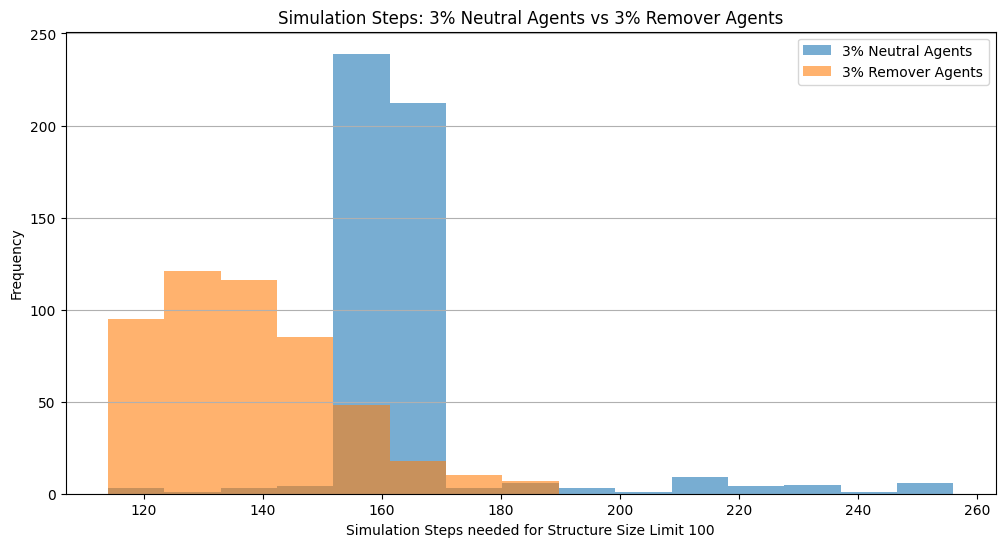

In [3]:
#Figure 11

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

neutral_file = "dataNEUTRAL/simulationstepscount.csv"
remover_file = "dataMAIN/simulationstepscount.csv"

spawn_column = "Factor 2"
result_column = "Result 1"

spawn_chance = 3   # compare 3% neutral agents vs 3% remover agents

# Load data
neutral_df = pd.read_csv(neutral_file)
remover_df = pd.read_csv(remover_file)

print("Neutral columns:", neutral_df.columns)
print("Remover columns:", remover_df.columns)

# Filter by spawn chance
neutral_steps = neutral_df[neutral_df[spawn_column] == spawn_chance][result_column].dropna()
remover_steps = remover_df[remover_df[spawn_column] == spawn_chance][result_column].dropna()

# Descriptive statistics function
def descriptive_statistics(values, label):
    values = pd.Series(values).dropna()

    n = len(values)
    mean = values.mean()
    sd = values.std(ddof=1)
    median = values.median()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    sem = sd / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_low = mean - t_crit * sem
    ci_high = mean + t_crit * sem

    return {
        "Group": label,
        "n": n,
        "Mean": mean,
        "SD": sd,
        "Median": median,
        "IQR": iqr,
        "95% CI lower": ci_low,
        "95% CI upper": ci_high
    }

summary_table = pd.DataFrame([
    descriptive_statistics(neutral_steps, f"{spawn_chance}% Neutral Agents"),
    descriptive_statistics(remover_steps, f"{spawn_chance}% Remover Agents")
])

summary_table_rounded = summary_table.round(3)

print("\nDescriptive statistics:")
print(summary_table_rounded)

# Welch's t-test
t_stat, p_two_sided = stats.ttest_ind(
    remover_steps,
    neutral_steps,
    equal_var=False
)

t_stat_one_sided, p_one_sided = stats.ttest_ind(
    remover_steps,
    neutral_steps,
    equal_var=False,
    alternative="less"
)

mean_difference = neutral_steps.mean() - remover_steps.mean()
relative_improvement = mean_difference / neutral_steps.mean() * 100


print("\nWelch's t-test:")
print("two-sided p =", p_two_sided)
print("one-sided p =", p_one_sided)
print("mean difference, neutral - remover =", mean_difference)
print("relative improvement of remover condition =", relative_improvement, "%")

# Mann-Whitney U test
u_stat, p_mw = stats.mannwhitneyu(
    remover_steps,
    neutral_steps,
    alternative="less"
)

print("\nMann-Whitney U test:")
print("U =", u_stat)
print("p =", p_mw)

# Histogram
combined = pd.concat([neutral_steps, remover_steps])

bins = np.linspace(
    combined.min(),
    combined.max(),
    16
)

plt.figure(figsize=(12, 6))

plt.hist(
    neutral_steps,
    bins=bins,
    alpha=0.6,
    label=f"{spawn_chance}% Neutral Agents"
)

plt.hist(
    remover_steps,
    bins=bins,
    alpha=0.6,
    label=f"{spawn_chance}% Remover Agents"
)

plt.xlabel("Simulation Steps needed for Structure Size Limit 100")
plt.ylabel("Frequency")
plt.title(f"Simulation Steps: {spawn_chance}% Neutral Agents vs {spawn_chance}% Remover Agents")
plt.legend()
plt.grid(axis="y")
plt.show()

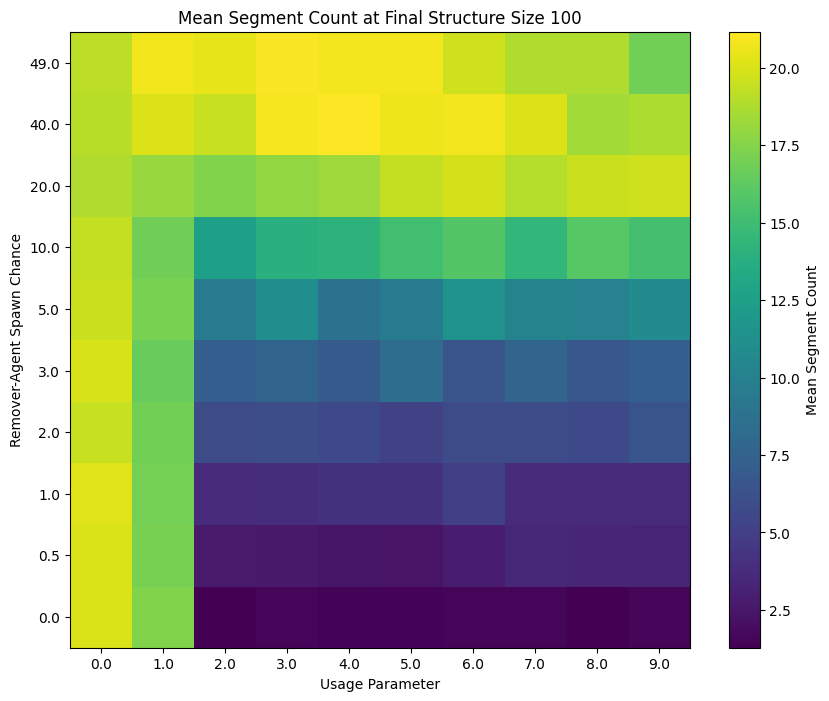

In [ ]:
#Figure 13
#Heatmap with aggregation for usage parameter pretrail

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataUSAGEPARAMETER/segmentcount.csv")

heatmap_data = (
    df.groupby(["Factor 2", "Factor 4"])["Result 1"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10, 8))

max_display = df["Result 1"].quantile(0.95)
img = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto"
    #vmax=max_display
)

plt.xlabel("Usage Parameter")
plt.ylabel("Remover-Agent Spawn Chance")
plt.title("Mean Segment Count at Final Structure Size 100")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(img, label="Mean Segment Count")
plt.show()

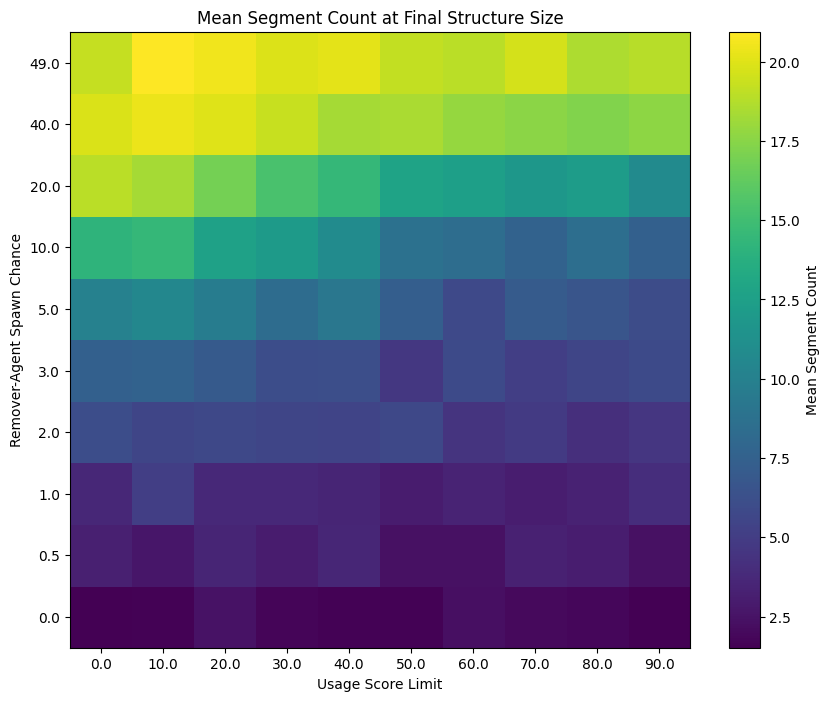

In [ ]:
#Figure 16
#Heatmap with aggregation for usage score limit pretrail

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataUSAGELIMIT/segmentcount.csv")

heatmap_data = (
    df.groupby(["Factor 2", "Factor 3"])["Result 1"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10, 8))

max_display = df["Result 1"].quantile(0.95)
img = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto"
    #vmax=max_display
)

plt.xlabel("Usage Score Limit")
plt.ylabel("Remover-Agent Spawn Chance")
plt.title("Mean Segment Count at Final Structure Size")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(img, label="Mean Segment Count")
plt.show()

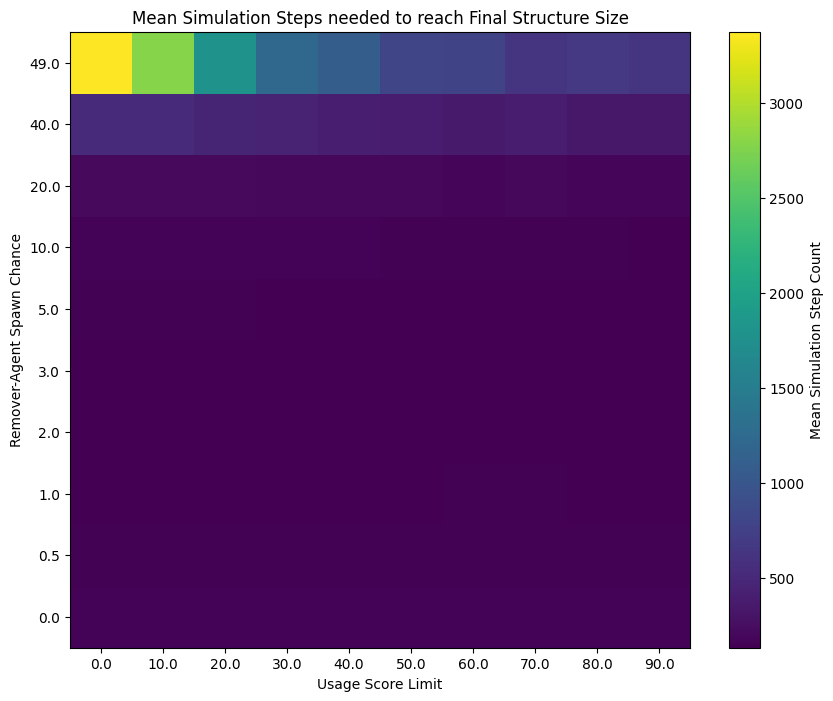

In [ ]:
#Figure 17
#Heatmap with aggregation for usage score limit pretrail

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataUSAGELIMIT/simulationstepscount.csv")

heatmap_data = (
    df.groupby(["Factor 2", "Factor 3"])["Result 1"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10, 8))

max_display = df["Result 1"].quantile(0.95)
img = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto"
    #vmax=max_display
)

plt.xlabel("Usage Score Limit")
plt.ylabel("Remover-Agent Spawn Chance")
plt.title("Mean Simulation Steps needed to reach Final Structure Size")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(img, label="Mean Simulation Step Count")
plt.show()

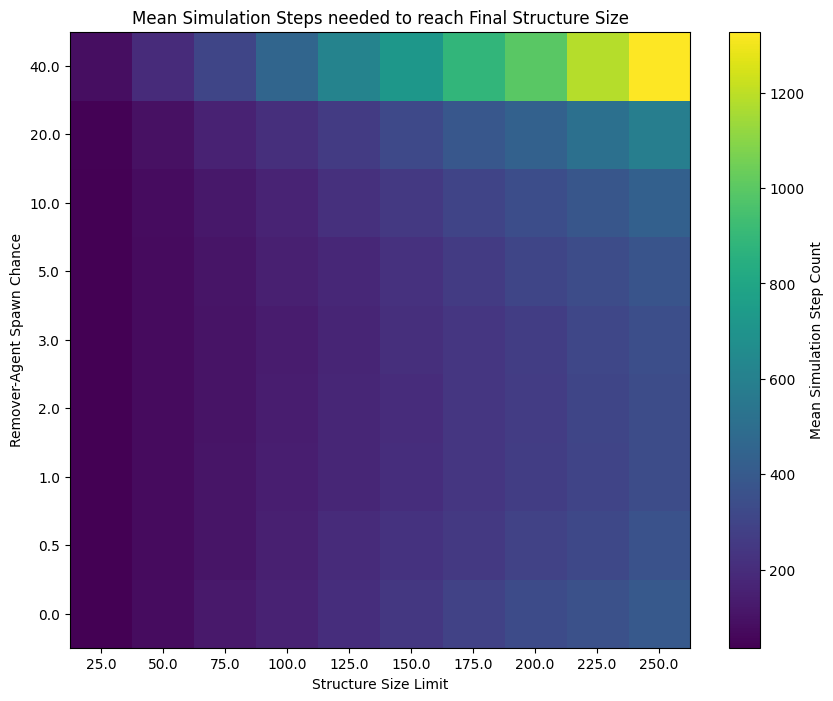

In [ ]:
#Figure 18
#Heatmap with aggregation for structure size limit pretrail

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataSIZELIMIT/simulationstepscount.csv")

heatmap_data = (
    df.groupby(["Factor 2", "Factor 5"])["Result 1"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10, 8))

max_display = df["Result 1"].quantile(0.95)
img = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto"
    #vmax=max_display
)

plt.xlabel("Structure Size Limit")
plt.ylabel("Remover-Agent Spawn Chance")
plt.title("Mean Simulation Steps needed to reach Final Structure Size")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(img, label="Mean Simulation Step Count")
plt.show()

In [4]:
#Appendix D.1 + D.2

import pandas as pd
import os

REMOVER_FOLDER = "dataMAIN"
NEUTRAL_FOLDER = "dataNEUTRAL"

spawn_col = "Factor 2"
result_col = "Result 1"

metric_files = {
    "Simulation steps": "simulationstepscount.csv",
    "Segment count": "segmentcount.csv",
    "Mean builder travel distance": "meantraveldistance.csv"
}

# descriptive statistics
def summarize_metric(filepath, metric_name):
    df = pd.read_csv(filepath)
    summary = (
        df.groupby(spawn_col)[result_col]
          .agg(
              n="count",
              mean="mean",
              SD="std",
              median="median",
              q1=lambda x: x.quantile(0.25),
              q3=lambda x: x.quantile(0.75)
          )
          .reset_index()
    )
    summary["IQR"] = summary["q3"] - summary["q1"]
    summary = summary[
        [spawn_col, "n", "mean", "SD", "median", "IQR"]
    ]
    summary = summary.set_index(spawn_col)
    summary.columns = pd.MultiIndex.from_product(
        [[metric_name], summary.columns]
    )
    return summary

# build appendix table
def build_condition_table(folder):
    summaries = []
    for metric_name, filename in metric_files.items():
        filepath = os.path.join(folder, filename)
        summary = summarize_metric(
            filepath,
            metric_name
        )
        summaries.append(summary)
    table = pd.concat(summaries, axis=1)
    table = table.sort_index()
    for metric in metric_files.keys():
        table[(metric, "mean")] = table[(metric, "mean")].round(3)
        table[(metric, "SD")] = table[(metric, "SD")].round(3)
        table[(metric, "median")] = table[(metric, "median")].round(3)
        table[(metric, "IQR")] = table[(metric, "IQR")].round(3)
    return table


# D.1 REMOVER-AGENT CONDITION

remover_table = build_condition_table(REMOVER_FOLDER)

print("\n")
print("=" * 100)
print("D.1 Remover-agent condition")
print("=" * 100)

print(remover_table.to_string())


# D.2 NEUTRAL-AGENT CONDITION

neutral_table = build_condition_table(NEUTRAL_FOLDER)

print("\n")
print("=" * 100)
print("D.2 Neutral-agent condition")
print("=" * 100)
print(neutral_table.to_string())

print("\nRemover spawn chances:")
print(remover_table.index.tolist())
print("\nNeutral spawn chances:")
print(neutral_table.index.tolist())




D.1 Remover-agent condition
         Simulation steps                                      Segment count                            Mean builder travel distance                               
                        n      mean        SD  median      IQR             n    mean     SD median  IQR                            n    mean     SD  median     IQR
Factor 2                                                                                                                                                           
0.0                   500   162.214    13.629   159.0     2.00           500   1.852  2.860    1.0  0.0                          500  30.876  5.144  29.385   1.066
0.5                   500   150.948    19.356   157.0    22.00           500   2.758  2.935    2.0  2.0                          500  26.248  7.317  28.541   8.555
1.0                   500   142.768    16.983   142.0    28.00           500   3.862  3.430    3.0  2.0                          500  22.704  6.802  2

In [6]:
#Appendix D.3 + D.4

import pandas as pd
import os

REMOVER_FOLDER = "dataMAIN"
NEUTRAL_FOLDER = "dataNEUTRAL"

spawn_col = "Factor 2"
result_col = "Result 1"

metric_files = {
    "Mean segment size": "meansegmentsize.csv",
    "Minimum segment size": "minsegmentsize.csv",
    "Maximum segment size": "maxsegmentsize.csv",
    "Segment-size SD": "stdsegmentsize.csv"
}

# descriptive statistics
def summarize_metric(filepath, metric_name):
    df = pd.read_csv(filepath)
    summary = (
        df.groupby(spawn_col)[result_col]
          .agg(
              n="count",
              mean="mean",
              SD="std",
              median="median",
              q1=lambda x: x.quantile(0.25),
              q3=lambda x: x.quantile(0.75)
          )
          .reset_index()
    )

    summary["IQR"] = summary["q3"] - summary["q1"]
    summary = summary[
        [spawn_col, "n", "mean", "SD", "median", "IQR"]
    ]
    summary = summary.set_index(spawn_col)
    summary.columns = pd.MultiIndex.from_product(
        [[metric_name], summary.columns]
    )
    return summary


# complete table
def build_condition_table(folder):
    summaries = []
    for metric_name, filename in metric_files.items():
        filepath = os.path.join(folder, filename)
        summary = summarize_metric(
            filepath,
            metric_name
        )
        summaries.append(summary)
    table = pd.concat(summaries, axis=1)
    table = table.sort_index()
    for metric in metric_files.keys():
        table[(metric, "mean")] = table[(metric, "mean")].round(3)
        table[(metric, "SD")] = table[(metric, "SD")].round(3)
        table[(metric, "median")] = table[(metric, "median")].round(3)
        table[(metric, "IQR")] = table[(metric, "IQR")].round(3)
    return table

# REMOVER-AGENT CONDITION
remover_table = build_condition_table(REMOVER_FOLDER)

print("\n")
print("=" * 120)
print("D.3 Segment-size statistics – Remover-agent condition")
print("=" * 120)
print(remover_table.to_string())

# NEUTRAL-AGENT CONDITION
neutral_table = build_condition_table(NEUTRAL_FOLDER)
print("\n")
print("=" * 120)
print("D.4 Segment-size statistics – Neutral-agent condition")
print("=" * 120)
print(neutral_table.to_string())

print("\nRemover spawn chances:")
print(remover_table.index.tolist())
print("\nNeutral spawn chances:")
print(neutral_table.index.tolist())



D.3 Segment-size statistics – Remover-agent condition
         Mean segment size                                  Minimum segment size                               Maximum segment size                               Segment-size SD                                
                         n    mean      SD   median     IQR                    n    mean      SD median    IQR                    n    mean      SD median    IQR               n    mean      SD  median     IQR
Factor 2                                                                                                                                                                                                         
0.0                    500  91.320  26.168  100.000   0.000                  500  90.228  29.348  100.0   0.00                  500  94.992  16.466  100.0   0.00             500   1.793   6.507   0.000   0.000
0.5                    500  63.841  36.156   50.000  66.667                  500  50.704  48.495   23.0 

In [10]:
# Appendix E

import argparse
import itertools
import numpy as np
import pandas as pd
from scipy import stats

RNG = np.random.default_rng(0)
N_BOOT = 10_000


def welch_report(a, b, label_a, label_b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    t, p = stats.ttest_ind(a, b, equal_var=False)
    dof = welch_dof(a, b)

    mean_diff = a.mean() - b.mean()
    se_diff = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    tcrit = stats.t.ppf(0.975, dof)
    ci = (mean_diff - tcrit * se_diff, mean_diff + tcrit * se_diff)
    u, p_u = stats.mannwhitneyu(a, b, alternative="two-sided")

    print(f"\n=== {label_a} (n={len(a)}) vs {label_b} (n={len(b)}) ===")
    print(f"Mean {label_a}: {a.mean():.3f} (SD {a.std(ddof=1):.3f}, "
          f"median {np.median(a):.1f}, IQR {stats.iqr(a):.1f})")
    print(f"Mean {label_b}: {b.mean():.3f} (SD {b.std(ddof=1):.3f}, "
          f"median {np.median(b):.1f}, IQR {stats.iqr(b):.1f})")
    print(f"Welch t({dof:.1f}) = {t:.2f}, p = {p:.3g}")
    print(f"Mean difference = {mean_diff:.3f}, 95% CI (Welch)   = "
          f"[{ci[0]:.2f}, {ci[1]:.2f}]")
    print(f"Mann-Whitney U = {u:.1f}, p = {p_u:.3g}  (distribution-free check)")
    return dict(t=t, p=p, dof=dof, mean_diff=mean_diff, ci=ci, u=u, p_u=p_u)


def welch_dof(a, b):
    va, vb = a.var(ddof=1), b.var(ddof=1)
    na, nb = len(a), len(b)
    num = (va / na + vb / nb) ** 2
    den = (va / na) ** 2 / (na - 1) + (vb / nb) ** 2 / (nb - 1)
    return num / den

def omnibus_and_dunnett(df, group_col, value_col, control_level):
    groups = [g[value_col].values for _, g in df.groupby(group_col)]
    print(f"\n=== Omnibus test across all {len(groups)} spawn chances ===")

    control = df[df[group_col] == control_level][value_col].values
    others = sorted(l for l in df[group_col].unique() if l != control_level)
    pvals = []
    for lvl in others:
        _, p = stats.mannwhitneyu(control, df[df[group_col] == lvl][value_col].values,
                                   alternative="two-sided")
        pvals.append(p)
    # Holm-Bonferroni step-down correction
    order = np.argsort(pvals)
    m = len(pvals)
    adj = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        corrected = (m - rank) * pvals[idx]
        running_max = max(running_max, corrected)
        adj[idx] = min(running_max, 1.0)
    print(f"Each spawn chance vs {control_level}% control "
          f"(Mann-Whitney U, Holm-adjusted):")
    for lvl, p, p_adj in zip(others, pvals, adj):
        flag = "significant" if p_adj < 0.05 else "n.s."
        print(f"  {control_level}% vs {lvl}%: raw p={p:.3g}, "
              f"Holm-adjusted p={p_adj:.3g}  [{flag}]")


def interaction_model(df_remover, df_neutral, group_col, value_col, spawn_col):
    import statsmodels.formula.api as smf

    r = df_remover[[spawn_col, value_col]].copy()
    r["agent_type"] = "remover"
    n = df_neutral[[spawn_col, value_col]].copy()
    n["agent_type"] = "neutral"
    combined = pd.concat([r, n], ignore_index=True)
    combined = combined.rename(columns={spawn_col: "spawn_chance", value_col: "steps"})

    model = smf.ols("steps ~ spawn_chance * C(agent_type)", data=combined).fit()
    print(model.summary().tables[1])



def main():
    remover_file = "dataMAIN/simulationstepscount.csv"
    neutral_file = "dataNEUTRAL/simulationstepscount.csv"

    value_col = "Result 1"
    spawn_col = "Factor 2"

    rem = pd.read_csv(remover_file)
    neu = pd.read_csv(neutral_file)

    a0 = rem.loc[rem[spawn_col] == 0,value_col].values
    a3 = rem.loc[rem[spawn_col] == 3,value_col].values
    welch_report(a0, a3, "0% remover", "3% remover")

    n3 = neu.loc[neu[spawn_col] == 3, value_col].values
    welch_report(n3, a3, "3% neutral", "3% remover")

    omnibus_and_dunnett(rem, spawn_col, value_col, control_level=0)

    try:
        interaction_model(rem, neu, spawn_col, value_col, spawn_col)
    except ImportError:
        print("\n(error)")


if __name__ == "__main__":
    main()


=== 0% remover (n=500) vs 3% remover (n=500) ===
Mean 0% remover: 162.214 (SD 13.629, median 159.0, IQR 2.0)
Mean 3% remover: 137.612 (SD 15.021, median 135.0, IQR 22.0)
Welch t(988.7) = 27.12, p = 1.5e-121
Mean difference = 24.602, 95% CI (Welch)   = [22.82, 26.38]
Mann-Whitney U = 226289.0, p = 1.55e-109  (distribution-free check)

=== 3% neutral (n=500) vs 3% remover (n=500) ===
Mean 3% neutral: 164.996 (SD 16.587, median 161.5, IQR 3.0)
Mean 3% remover: 137.612 (SD 15.021, median 135.0, IQR 22.0)
Welch t(988.3) = 27.36, p = 3.62e-123
Mean difference = 27.384, 95% CI (Welch)   = [25.42, 29.35]
Mann-Whitney U = 230505.0, p = 2.4e-118  (distribution-free check)

=== Omnibus test across all 10 spawn chances ===
Each spawn chance vs 0% control (Mann-Whitney U, Holm-adjusted):
  0% vs 0.5%: raw p=7.91e-33, Holm-adjusted p=1.58e-32  [significant]
  0% vs 1.0%: raw p=1.86e-82, Holm-adjusted p=7.43e-82  [significant]
  0% vs 2.0%: raw p=4.68e-102, Holm-adjusted p=2.34e-101  [significant]
 